In [1]:
import pandas as pd

In [2]:
risk_df = pd.read_csv(
    "../data/processed/crime_risk_scores.csv"
)

anomaly_df = pd.read_csv(
    "../data/processed/district_anomalies.csv"
)

hotspot_df = pd.read_csv(
    "../data/processed/crime_hotspots.csv"
)

In [3]:
risk_df.head()

,district,crime_count,repeat_offenders,crime_score,offender_score,CRI,Risk_Level
0,Tumakuru,1027,215,98.465964,98.173516,98.378229,Critical
1,Shivamogga,1043,206,100.000000,94.063927,98.219178,Critical
2,Mangaluru,1028,210,98.561841,95.890411,97.760412,Critical
3,Mysuru,1004,219,96.260786,100.000000,97.382550,Critical
4,Dharwad,1014,208,97.219559,94.977169,96.546842,Critical


In [4]:
anomaly_df.head()

,district,anomaly_count
0,Kalaburagi,51
1,Belagavi,45
2,Mangaluru,29
3,Bengaluru Urban,28
4,Mysuru,18


In [5]:
hotspot_df.head()

,cluster,crime_count
0,0,879
1,1,900
2,2,937
3,3,865
4,4,947


In [6]:
hotspot_df.columns

Index(['cluster', 'crime_count'], dtype='str')

In [9]:
hotspot_df.columns

Index(['cluster', 'crime_count'], dtype='str')

In [10]:
hotspot_df.head()

,cluster,crime_count
0,0,879
1,1,900
2,2,937
3,3,865
4,4,947


In [12]:
risk_df.columns

Index(['district', 'crime_count', 'repeat_offenders', 'crime_score',
       'offender_score', 'CRI', 'Risk_Level'],
      dtype='str')

In [13]:
anomaly_df.columns

Index(['district', 'anomaly_count'], dtype='str')

In [15]:
patrol_df = risk_df.merge(
    anomaly_df,
    on="district",
    how="left"
)

patrol_df.head()

,district,crime_count,repeat_offenders,crime_score,offender_score,CRI,Risk_Level,anomaly_count
0,Tumakuru,1027,215,98.465964,98.173516,98.378229,Critical,2
1,Shivamogga,1043,206,100.000000,94.063927,98.219178,Critical,3
2,Mangaluru,1028,210,98.561841,95.890411,97.760412,Critical,29
3,Mysuru,1004,219,96.260786,100.000000,97.382550,Critical,18
4,Dharwad,1014,208,97.219559,94.977169,96.546842,Critical,7


In [16]:
patrol_df["anomaly_count"] = (
    patrol_df["anomaly_count"]
    .fillna(0)
)

In [17]:
patrol_df["priority_score"] = (
    patrol_df["CRI"] * 0.8 +
    patrol_df["anomaly_count"] * 0.2
)

In [18]:
patrol_df = patrol_df.sort_values(
    by="priority_score",
    ascending=False
)

patrol_df["patrol_rank"] = range(
    1,
    len(patrol_df)+1
)

In [19]:
risk_df.columns

Index(['district', 'crime_count', 'repeat_offenders', 'crime_score',
       'offender_score', 'CRI', 'Risk_Level'],
      dtype='str')

In [20]:
patrol_df.head()

,district,crime_count,repeat_offenders,crime_score,offender_score,CRI,Risk_Level,anomaly_count,priority_score,patrol_rank
2,Mangaluru,1028,210,98.561841,95.890411,97.760412,Critical,29,84.008330,1
6,Belagavi,969,209,92.905081,95.433790,93.663694,Critical,45,83.930955,2
8,Kalaburagi,960,191,92.042186,87.214612,90.593914,Critical,51,82.675131,3
3,Mysuru,1004,219,96.260786,100.000000,97.382550,Critical,18,81.506040,4
5,Bengaluru Urban,1002,194,96.069032,88.584475,93.823665,Critical,28,80.658932,5


In [21]:
def recommend(score):

    if score >= 80:
        return "Immediate Patrol"

    elif score >= 60:
        return "High Priority"

    elif score >= 40:
        return "Medium Priority"

    else:
        return "Routine Monitoring"


patrol_df["recommendation"] = patrol_df[
    "priority_score"
].apply(recommend)

In [22]:
patrol_df[
[
    "patrol_rank",
    "district",
    "priority_score",
    "recommendation"
]
]

,patrol_rank,district,priority_score,recommendation
2,1,Mangaluru,84.008330,Immediate Patrol
6,2,Belagavi,83.930955,Immediate Patrol
8,3,Kalaburagi,82.675131,Immediate Patrol
3,4,Mysuru,81.506040,Immediate Patrol
5,5,Bengaluru Urban,80.658932,Immediate Patrol
1,6,Shivamogga,79.175342,High Priority
0,7,Tumakuru,79.102583,High Priority
4,8,Dharwad,78.637474,High Priority
9,9,Vijayapura,75.038981,High Priority
7,10,Ballari,74.863915,High Priority


In [23]:
patrol_df.to_csv(
    "../data/processed/district_patrol_priority.csv",
    index=False
)

print("Patrol recommendations saved")

Patrol recommendations saved


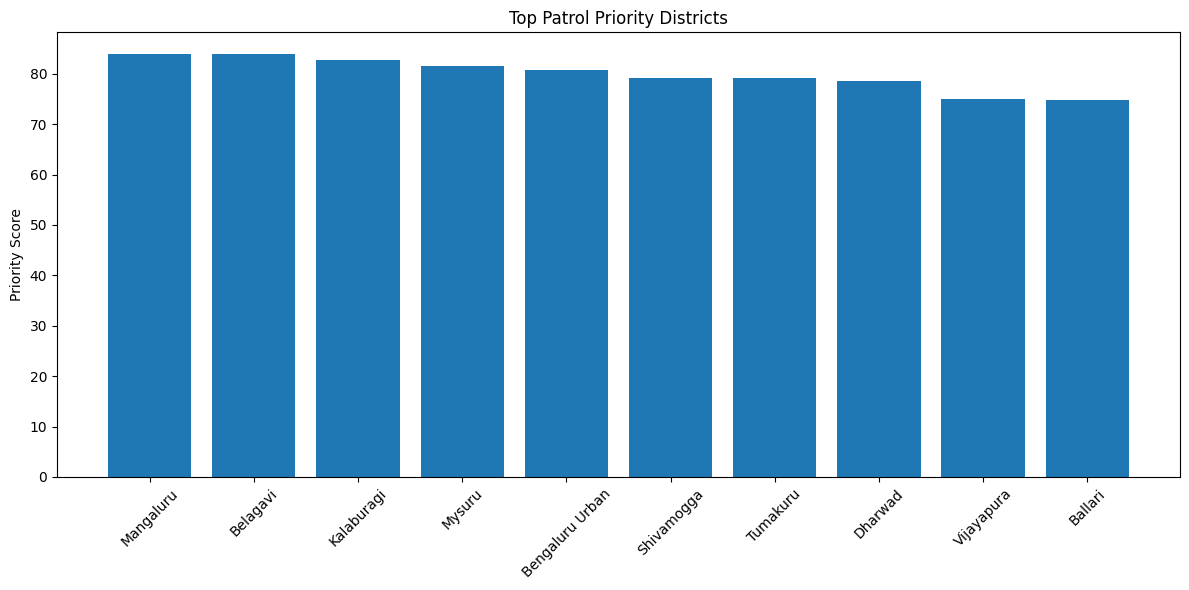

In [24]:
import matplotlib.pyplot as plt

top10 = patrol_df.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["district"],
    top10["priority_score"]
)

plt.xticks(rotation=45)

plt.ylabel("Priority Score")

plt.title(
    "Top Patrol Priority Districts"
)

plt.tight_layout()

plt.show()

# Patrol Recommendation System

## Objective

Prioritize police patrol deployment based on:

- Crime Risk Index (CRI)
- Detected anomalies

## Methodology

Priority Score = 0.8 × CRI + 0.2 × Anomaly Count

## Outcome

Districts are ranked according to operational priority, enabling efficient police resource allocation and proactive crime prevention.